In [3]:

import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from IPython.display import display, Markdown


In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


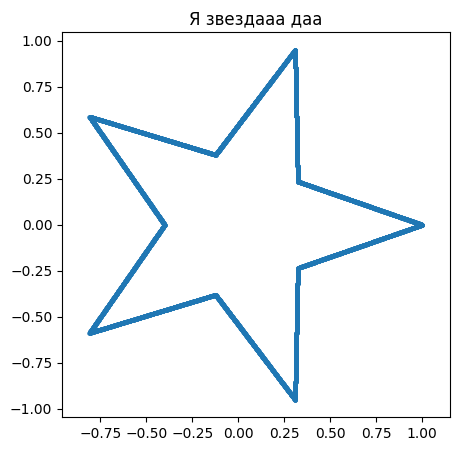

In [5]:

def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=5000, center=(0.0, 0.0)):
    angle_step = np.pi / n_spikes
    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius
        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices, dtype=np.float32)
    points = []
    per_edge = max(2, n_samples // (len(vertices) - 1))

    for i in range(len(vertices) - 1):
        a = vertices[i]
        b = vertices[i + 1]
        for t in np.linspace(0.0, 1.0, per_edge, endpoint=False):
            points.append((1.0 - t) * a + t * b)

    points = np.array(points, dtype=np.float32)
    if len(points) < n_samples:
        extra_idx = np.random.choice(len(points), size=n_samples - len(points), replace=True)
        points = np.concatenate([points, points[extra_idx]], axis=0)
    else:
        points = points[:n_samples]
    return points

star = generate_star(n_samples=5000)

plt.figure(figsize=(5, 5))
plt.scatter(star[:, 0], star[:, 1], s=5)
plt.axis("equal")
plt.title("Я звездааа даа")
plt.show()


In [6]:

@dataclass
class Config:
    lr: float = 1e-3
    epochs: int = 400
    batch_size: int = 512
    hidden_dim: int = 256
    time_dim: int = 64
    num_steps: int = 400
    data_samples: int = 5000
    eval_samples: int = 1200
    beta_min: float = 0.1
    beta_max_linear: float = 10.0
    beta_max_cosine: float = 20.0
    cosine_s: float = 0.008
    eps_t: float = 1e-4
    grad_clip: float = 1.0

config = Config()


In [7]:

def timestep_embedding(t, dim, max_period=10000):
    if t.ndim == 1:
        t = t[:, None]
    half = dim // 2
    freqs = torch.exp(-math.log(max_period) * torch.arange(0, half, device=t.device) / half)
    args = t * freqs[None]
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    if dim % 2:
        emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=-1)
    return emb

class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.time_dim = config.time_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(config.time_dim, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.SiLU(),
        )
        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, 2),
        )

    def forward(self, x, t):
        t_emb = self.time_mlp(timestep_embedding(t, self.time_dim))
        return self.net(torch.cat([x, t_emb], dim=1))

class VPSDE:
    def __init__(self, config, schedule="linear"):
        self.config = config
        self.schedule = schedule
        self.beta_min = config.beta_min
        self.beta_max = config.beta_max_linear if schedule == "linear" else config.beta_max_cosine
        self.cosine_s = config.cosine_s
        self.eps_t = config.eps_t
        self.cosine_norm = math.cos((self.cosine_s / (1.0 + self.cosine_s)) * math.pi / 2.0) ** 2

    def _clip_t(self, t):
        return t.clamp(self.eps_t, 1.0 - self.eps_t)

    def alpha_bar_cosine(self, t):
        t = self._clip_t(t)
        angle = (t + self.cosine_s) / (1.0 + self.cosine_s) * math.pi / 2.0
        alpha_bar = (torch.cos(angle) ** 2) / self.cosine_norm
        return alpha_bar.clamp(min=1e-5, max=1.0)

    def int_beta(self, t):
        t = self._clip_t(t)
        if self.schedule == "linear":
            return self.beta_min * t + 0.5 * (self.beta_max - self.beta_min) * t ** 2
        if self.schedule == "cosine":
            return -torch.log(self.alpha_bar_cosine(t))
        raise ValueError(self.schedule)

    def beta(self, t):
        t = self._clip_t(t)
        if self.schedule == "linear":
            return self.beta_min + (self.beta_max - self.beta_min) * t
        if self.schedule == "cosine":
            angle = (t + self.cosine_s) / (1.0 + self.cosine_s) * math.pi / 2.0
            beta_t = (math.pi / (1.0 + self.cosine_s)) * torch.tan(angle)
            return beta_t.clamp(min=self.beta_min, max=self.beta_max)
        raise ValueError(self.schedule)

    def mean_coeff(self, t):
        return torch.exp(-0.5 * self.int_beta(t))

    def std(self, t):
        return torch.sqrt((1.0 - torch.exp(-self.int_beta(t))).clamp(min=1e-5))

    def marginal_prob(self, x0, t):
        mean_coeff = self.mean_coeff(t)
        std = self.std(t)
        return mean_coeff * x0, std


In [8]:

def get_loss_weights(weighting, mean_coeff, std):
    snr = mean_coeff.pow(2) / std.pow(2).clamp(min=1e-5)

    if weighting == "uniform":
        w = torch.ones_like(std)
    elif weighting == "sigma2":
        w = std.pow(2)
    elif weighting == "snr_clip":
        w = snr.clamp(max=5.0)
    else:
        raise ValueError(weighting)

    return w / w.mean().clamp(min=1e-8)

def symmetric_chamfer_distance(x, y):
    dists = torch.cdist(x, y)
    return 0.5 * (dists.min(dim=1).values.mean() + dists.min(dim=0).values.mean())

def sample_reverse_sde(model, sde, num_samples, num_steps, device):
    model.eval()
    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device)
        dt = 1.0 / num_steps

        for i in range(num_steps):
            t = max(1.0 - i * dt, sde.eps_t)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            beta_t = sde.beta(t_tensor)
            std_t = sde.std(t_tensor)

            eps_pred = model(x, t_tensor)
            score = -eps_pred / std_t

            drift = 0.5 * beta_t * x + beta_t * score
            noise = torch.randn_like(x) if i < num_steps - 1 else torch.zeros_like(x)

            x = x + drift * dt + torch.sqrt(beta_t * dt) * noise

        return x.cpu()

def sample_pf_ode(model, sde, num_samples, num_steps, device):
    model.eval()
    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device)
        dt = 1.0 / num_steps

        for i in range(num_steps):
            t = max(1.0 - i * dt, sde.eps_t)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            beta_t = sde.beta(t_tensor)
            std_t = sde.std(t_tensor)

            eps_pred = model(x, t_tensor)
            score = -eps_pred / std_t

            drift = 0.5 * beta_t * x + 0.5 * beta_t * score
            x = x + drift * dt

        return x.cpu()


In [9]:

class VPTrainer:
    def __init__(self, config, schedule="linear", weighting="uniform"):
        self.config = config
        self.schedule = schedule
        self.weighting = weighting
        self.device = device

        self.data = torch.tensor(generate_star(n_samples=config.data_samples), dtype=torch.float32)
        self.dataset = TensorDataset(self.data)
        self.loader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)
        self.sde = VPSDE(config, schedule=schedule)
        self.loss_history = []

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (x0,) in self.loader:
            x0 = x0.to(self.device)

            t = torch.rand(x0.shape[0], 1, device=self.device)
            t = t * (1.0 - 2.0 * self.sde.eps_t) + self.sde.eps_t

            mean, std = self.sde.marginal_prob(x0, t)
            z = torch.randn_like(x0)
            x_t = mean + std * z

            eps_pred = self.model(x_t, t)
            weights = get_loss_weights(self.weighting, self.sde.mean_coeff(t), std)

            per_sample_loss = ((eps_pred - z) ** 2).sum(dim=1, keepdim=True)
            loss = (weights * per_sample_loss).mean()

            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.grad_clip)
            self.optimizer.step()

            total_loss += loss.item() * x0.shape[0]

        return total_loss / len(self.dataset)

    def fit(self, verbose=True):
        for epoch in range(1, self.config.epochs + 1):
            loss = self.train_epoch()
            self.loss_history.append(loss)
            if verbose and (epoch == 1 or epoch % 50 == 0 or epoch == self.config.epochs):
                print(f"schedule={self.schedule:>6} | weight={self.weighting:>8} | epoch={epoch:>4} | loss={loss:.6f}")
        return self


In [10]:

def run_experiment(schedule, weighting, seed=42, sampler="sde"):
    set_seed(seed)

    trainer = VPTrainer(config, schedule=schedule, weighting=weighting)
    trainer.fit(verbose=True)

    if sampler == "sde":
        samples = sample_reverse_sde(
            trainer.model,
            trainer.sde,
            num_samples=config.eval_samples,
            num_steps=config.num_steps,
            device=device,
        )
    else:
        samples = sample_pf_ode(
            trainer.model,
            trainer.sde,
            num_samples=config.eval_samples,
            num_steps=config.num_steps,
            device=device,
        )

    ref = torch.tensor(generate_star(n_samples=config.eval_samples), dtype=torch.float32)
    chamfer = symmetric_chamfer_distance(samples, ref).item()

    return {
        "schedule": schedule,
        "weight": weighting,
        "loss_history": trainer.loss_history,
        "samples": samples.numpy(),
        "chamfer": chamfer,
    }

schedules = ["linear", "cosine"]
weights = ["uniform", "sigma2", "snr_clip"]

results = []
for schedule in schedules:
    for weight in weights:
        results.append(run_experiment(schedule, weight, seed=42, sampler="sde"))


schedule=linear | weight= uniform | epoch=   1 | loss=1.851251
schedule=linear | weight= uniform | epoch=  50 | loss=0.508899
schedule=linear | weight= uniform | epoch= 100 | loss=0.471610
schedule=linear | weight= uniform | epoch= 150 | loss=0.475884
schedule=linear | weight= uniform | epoch= 200 | loss=0.492331
schedule=linear | weight= uniform | epoch= 250 | loss=0.500060
schedule=linear | weight= uniform | epoch= 300 | loss=0.488222
schedule=linear | weight= uniform | epoch= 350 | loss=0.509106
schedule=linear | weight= uniform | epoch= 400 | loss=0.480007
schedule=linear | weight=  sigma2 | epoch=   1 | loss=1.802648
schedule=linear | weight=  sigma2 | epoch=  50 | loss=0.158597
schedule=linear | weight=  sigma2 | epoch= 100 | loss=0.157947
schedule=linear | weight=  sigma2 | epoch= 150 | loss=0.156843
schedule=linear | weight=  sigma2 | epoch= 200 | loss=0.157680
schedule=linear | weight=  sigma2 | epoch= 250 | loss=0.160215
schedule=linear | weight=  sigma2 | epoch= 300 | loss=0

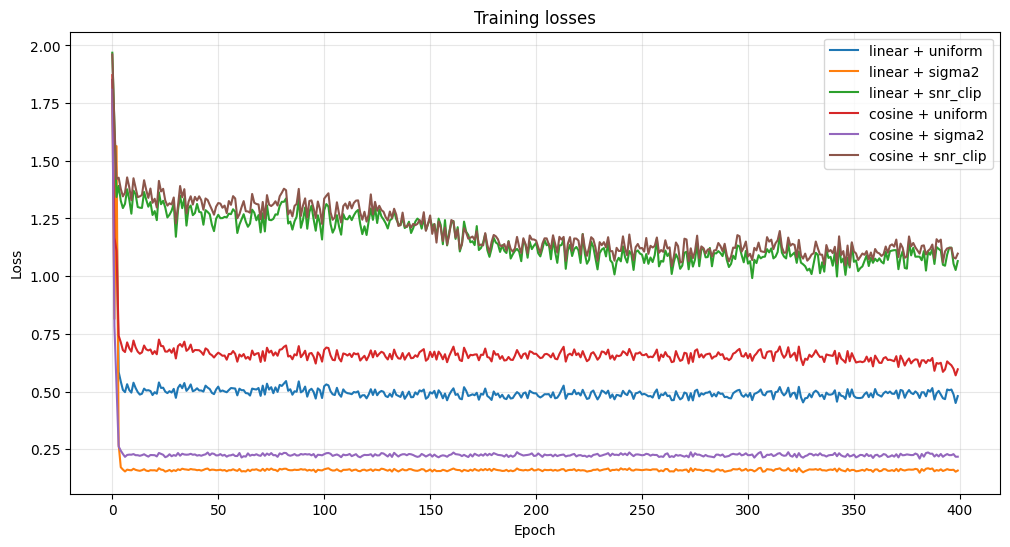

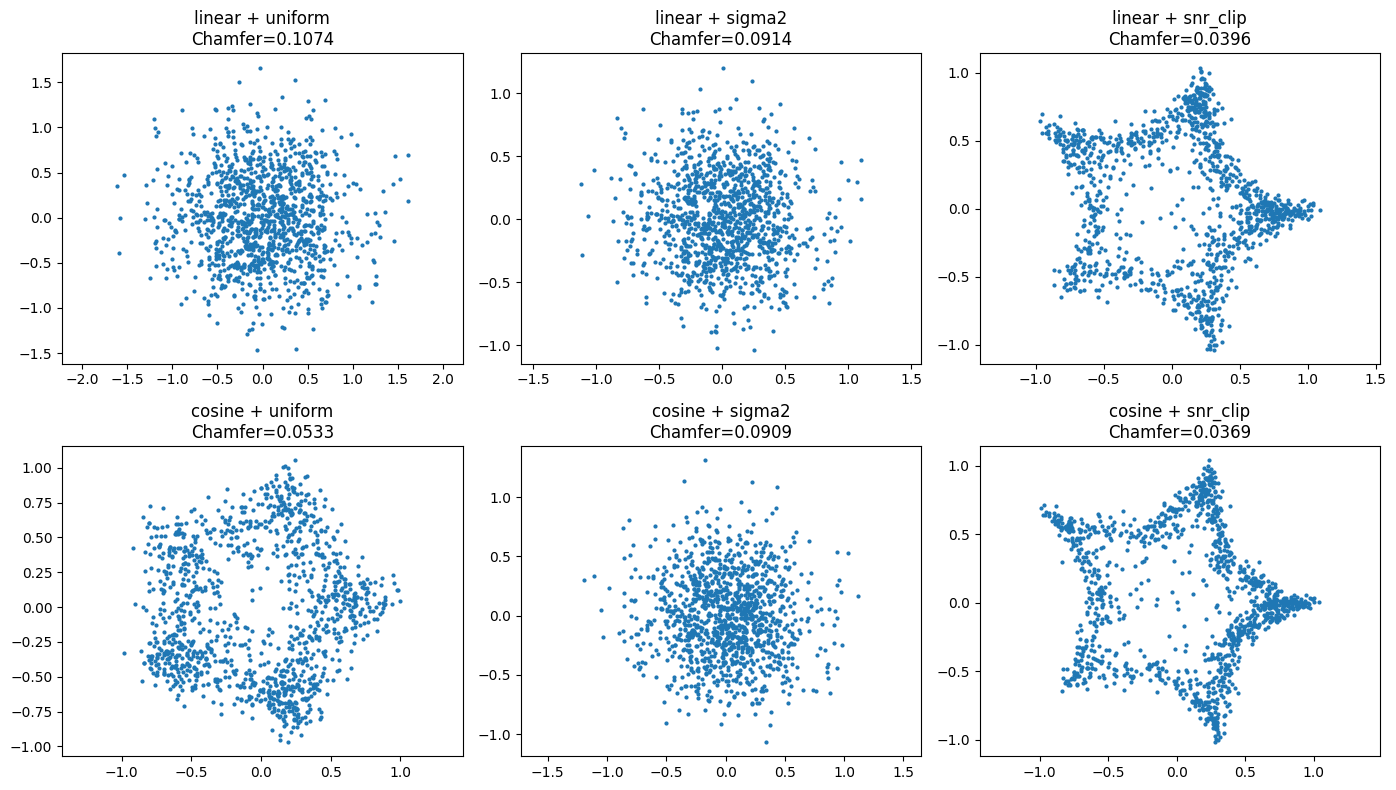

In [11]:

plt.figure(figsize=(12, 6))
for result in results:
    label = f"{result['schedule']} + {result['weight']}"
    plt.plot(result["loss_history"], label=label)
plt.title("Training losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

fig, axes = plt.subplots(len(schedules), len(weights), figsize=(14, 8))
for i, schedule in enumerate(schedules):
    for j, weight in enumerate(weights):
        ax = axes[i, j]
        result = next(r for r in results if r["schedule"] == schedule and r["weight"] == weight)
        samples = result["samples"]
        ax.scatter(samples[:, 0], samples[:, 1], s=4)
        ax.set_title(f"{schedule} + {weight}\nChamfer={result['chamfer']:.4f}")
        ax.axis("equal")
plt.tight_layout()
plt.show()


In [15]:

summary = pd.DataFrame(
    [
        {
            "schedule": r["schedule"],
            "weight": r["weight"],
            "chamfer": r["chamfer"],
            "final_loss": r["loss_history"][-1],
            "min_loss": min(r["loss_history"]),
        }
        for r in results
    ]
).sort_values("chamfer", ascending=True).reset_index(drop=True)

display(summary)

best = summary.iloc[0]
schedule_mean = summary.groupby("schedule")["chamfer"].mean().sort_values()
weight_mean = summary.groupby("weight")["chamfer"].mean().sort_values()


,schedule,weight,chamfer,final_loss,min_loss
0,cosine,snr_clip,0.036924,1.097654,1.043226
1,linear,snr_clip,0.039610,1.065332,0.991595
2,cosine,uniform,0.053338,0.596252,0.569967
3,cosine,sigma2,0.090865,0.217457,0.209123
4,linear,sigma2,0.091423,0.157416,0.147954
5,linear,uniform,0.107432,0.480007,0.450184


Вывод

Лучший результат по symmetric Chamfer: cosine + snr_clip.

Так, ну в общем, VP-SDE работает и генерирует звезду. При сравнении расписаний лучше cosine, а среди вариантов перезвешивания лучше snr_clip. Это видно и по loss кривым, и по итоговым scatter графикам форма звезды получается четче